In [2]:
# --- Cell 1: Imports ---
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from collections import deque

In [3]:
# --- Cell 2: Table Tennis Environment ---
class TableTennisEnv:
    def __init__(self):
        self.width = 1.0
        self.height = 1.0
        self.dt = 0.05
        self.paddle_speed = 1.0
        self.reset()

    def reset(self):
        self.ball_pos = np.array([0.9, np.random.uniform(0.2, 0.8)])
        self.ball_vel = np.array([-0.5, np.random.uniform(-0.5, 0.5)])
        self.paddle_y = 0.5
        self.done = False
        return self._get_state()

    def step(self, action):
        self.paddle_y += action[0] * self.paddle_speed * self.dt
        self.paddle_y = np.clip(self.paddle_y, 0, 1)
        self.ball_pos += self.ball_vel * self.dt

        if self.ball_pos[1] <= 0 or self.ball_pos[1] >= self.height:
            self.ball_vel[1] *= -1

        reward = 0.0
        if self.ball_pos[0] <= 0.05:
            dist = abs(self.ball_pos[1] - self.paddle_y)
            if dist < 0.1:
                self.ball_vel[0] *= -1
                reward = max(0, 1.0 - dist * 3)

            else:
                reward = -1.0
                self.done = True

        if self.ball_pos[0] < 0:
            self.done = True

        return self._get_state(), reward, self.done, {}

    def _get_state(self):
        return np.concatenate([self.ball_pos, self.ball_vel, [self.paddle_y]])

In [4]:
# --- Cell 3: Actor & Critic Networks ---
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return torch.tanh(self.out(x))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.out(x)


In [5]:
# --- Cell 4: Replay Buffer ---
class ReplayBuffer:
    def __init__(self, size=100000, batch_size=64):
        self.memory = deque(maxlen=size)
        self.batch_size = batch_size

    def add(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self):
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (np.vstack(states), np.vstack(actions), np.vstack(rewards),
                np.vstack(next_states), np.vstack(dones))

    def __len__(self):
        return len(self.memory)

In [6]:
# --- Cell 5: DDPG Agent ---
class DDPGAgent:
    def __init__(self, state_dim, action_dim):
        self.actor = Actor(state_dim, action_dim)
        self.actor_target = Actor(state_dim, action_dim)
        self.critic = Critic(state_dim, action_dim)
        self.critic_target = Critic(state_dim, action_dim)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)
        self.buffer = ReplayBuffer()
        self.gamma = 0.99
        self.tau = 1e-3
        self.learn_step = 0

        self.soft_update(1.0)

    def act(self, state, noise=0.1):
        state = torch.FloatTensor(state).unsqueeze(0)
        action = self.actor(state).detach().numpy()[0]
        action += noise * np.random.randn(*action.shape)
        return np.clip(action, -1, 1)

    def step(self, state, action, reward, next_state, done):
        self.buffer.add(state, action, reward, next_state, done)
        self.learn_step += 1
        if len(self.buffer) > self.buffer.batch_size and self.learn_step % 10 == 0:
            self.learn()

    def learn(self):
        states, actions, rewards, next_states, dones = self.buffer.sample()
        states = torch.FloatTensor(states)
        actions = torch.FloatTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones = torch.FloatTensor(dones)

        with torch.no_grad():
            next_actions = self.actor_target(next_states)
            q_targets_next = self.critic_target(next_states, next_actions)
            q_targets = rewards + self.gamma * q_targets_next * (1 - dones)

        q_expected = self.critic(states, actions)
        critic_loss = nn.MSELoss()(q_expected, q_targets)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -self.critic(states, self.actor(states)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        self.soft_update(self.tau)

    def soft_update(self, tau):
        for target, local in zip(self.actor_target.parameters(), self.actor.parameters()):
            target.data.copy_(tau * local.data + (1.0 - tau) * target.data)
        for target, local in zip(self.critic_target.parameters(), self.critic.parameters()):
            target.data.copy_(tau * local.data + (1.0 - tau) * target.data)


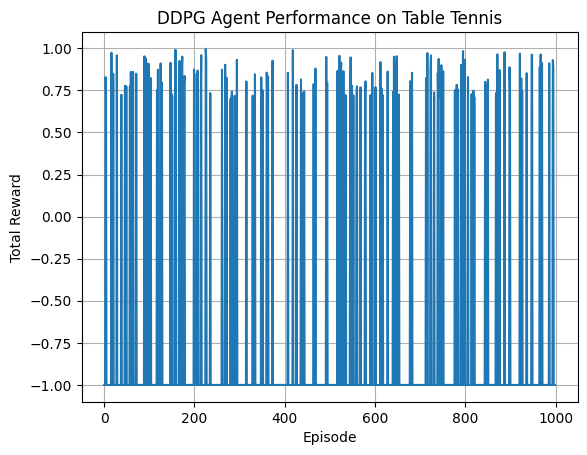

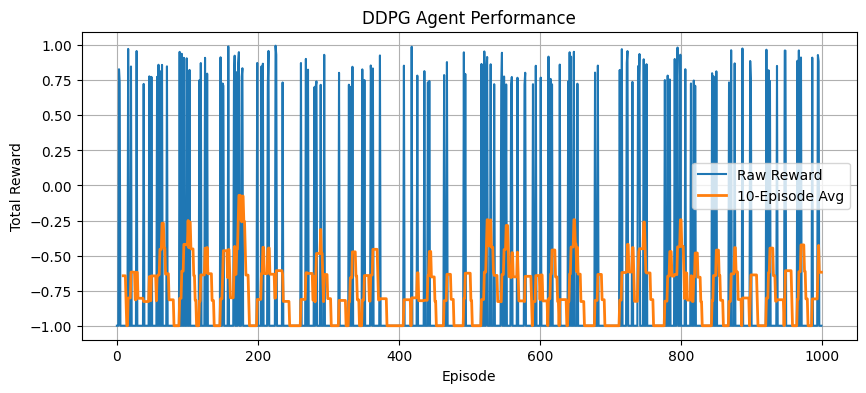

In [7]:
# --- Cell 6: Training Loop ---
env = TableTennisEnv()
agent = DDPGAgent(state_dim=5, action_dim=1)
scores = []

for episode in range(1, 1001):
    state = env.reset()
    total_reward = 0
    for t in range(300):
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        agent.step(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break
    scores.append(total_reward)
    #print(f"Episode {episode}: Total Reward = {total_reward:.2f}")


plt.plot(scores)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DDPG Agent Performance on Table Tennis")
plt.grid(True)
plt.show()

import pandas as pd

plt.figure(figsize=(10, 4))
plt.plot(scores, label='Raw Reward')
plt.plot(pd.Series(scores).rolling(10).mean(), label='10-Episode Avg', linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DDPG Agent Performance")
plt.legend()
plt.grid(True)
plt.show()

